In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.interpolate import griddata
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/all_94_cities_historical_combined.csv')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        10,
})

df

,city,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,wind_gusts_10m_max,relative_humidity_2m_mean,pressure_msl_mean,cloud_cover_mean,shortwave_radiation_sum,apparent_temperature_max,weather_code,latitude,longitude
0,absheron,2020-01-01,11.6,3.4,6.1,0.0,0.0,0.0,14.7,26.6,88,1013.4,15,8.29,9.7,3,40.49,49.75
1,absheron,2020-01-02,8.4,2.3,5.8,0.0,0.0,0.0,32.3,61.9,87,1019.7,49,7.46,2.7,3,40.49,49.75
2,absheron,2020-01-03,6.7,3.8,5.2,2.2,2.2,0.0,25.6,48.2,87,1026.7,96,3.24,2.8,51,40.49,49.75
3,absheron,2020-01-04,8.1,3.7,6.2,0.4,0.4,0.0,21.7,41.8,85,1020.8,99,2.55,4.4,51,40.49,49.75
4,absheron,2020-01-05,6.8,6.1,6.4,3.8,3.8,0.0,14.1,26.6,92,1015.0,100,1.63,5.1,53,40.49,49.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215923,zardab,2026-04-15,16.9,7.8,12.2,0.0,0.0,0.0,19.3,35.6,54,1022.4,22,22.55,15.6,3,40.22,47.71
215924,zardab,2026-04-16,18.5,5.2,12.1,0.2,0.2,0.0,10.1,20.2,70,1021.6,5,22.16,18.4,51,40.22,47.71
215925,zardab,2026-04-17,19.5,7.2,13.5,0.0,0.0,0.0,12.0,24.5,72,1021.8,27,21.36,18.7,3,40.22,47.71
215926,zardab,2026-04-18,20.5,8.0,14.1,0.1,0.1,0.0,10.9,23.0,76,1014.6,61,20.64,20.5,51,40.22,47.71


In [2]:
import os
os.makedirs("reports/figures/", exist_ok=True)

counter = 1

def auto_save(name=None):
    global counter
    suffix = f"_{name}" if name else ""
    path = f"../reports/figures/plot_{counter}{suffix}.png"
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {path}")
    counter += 1

In [3]:
df['time'] = pd.to_datetime(df['time'])
df.info()
TOP_CITIES = ['Baku', 'Ganja', 'Lankaran', 'Nakhchivan','Sheki', 'Sumqayit', 'Sabirabad','Mingachevir','Saatli','Imishli']

<class 'pandas.DataFrame'>
RangeIndex: 215928 entries, 0 to 215927
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   city                       215928 non-null  str           
 1   time                       215928 non-null  datetime64[us]
 2   temperature_2m_max         215928 non-null  float64       
 3   temperature_2m_min         215928 non-null  float64       
 4   temperature_2m_mean        215928 non-null  float64       
 5   precipitation_sum          215928 non-null  float64       
 6   rain_sum                   215928 non-null  float64       
 7   snowfall_sum               215928 non-null  float64       
 8   wind_speed_10m_max         215928 non-null  float64       
 9   wind_gusts_10m_max         215928 non-null  float64       
 10  relative_humidity_2m_mean  215928 non-null  int64         
 11  pressure_msl_mean          215928 non-null  float64       
 12 

# Task 1 — Descriptive Statistics

In [4]:
df['city'] = df['city'].astype(str).str.strip().str.title()
TOP_CITIES = [c.strip().title() for c in TOP_CITIES]

In [ ]:
from scipy import stats

def summary_table(df, cities, cols):
    records = []
    for city in cities:
        sub = df[df['city'].str.strip() == city]
        
        for col in cols:
            s = pd.to_numeric(sub[col], errors='coerce').dropna()
            
            if len(s) > 0:
                records.append({
                    'City':     city,
                    'Variable': col,
                    'Count':    int(s.count()),
                    'Mean':     round(s.mean(), 3),
                    'Std':      round(s.std(), 3),
                    'Min':      round(s.min(), 3),
                    'Q1':       round(s.quantile(0.25), 3),
                    'Median':   round(s.median(), 3),
                    'Q3':       round(s.quantile(0.75), 3),
                    'Max':      round(s.max(), 3),
                    'Skewness': round(stats.skew(s), 3) if len(s) > 2 else 0,
                    'Kurtosis': round(stats.kurtosis(s), 3) if len(s) > 2 else 0,
                })
            else:
                records.append({
                    'City': city, 'Variable': col, 'Count': 0, 
                    'Mean': 0, 'Std': 0, 'Min': 0, 'Q1': 0, 
                    'Median': 0, 'Q3': 0, 'Max': 0, 'Skewness': 0, 'Kurtosis': 0
                })
    return pd.DataFrame(records)

key_vars = ['temperature_2m_max', 'temperature_2m_min',
            'precipitation_sum', 'wind_speed_10m_max',
            'relative_humidity_2m_mean']

summary_df = summary_table(df, TOP_CITIES, key_vars)
styled = (summary_df
          .set_index(['City','Variable'])
          .style
          .background_gradient(subset=['Mean'],  cmap='RdYlBu_r')
          .background_gradient(subset=['Std'],   cmap='YlOrRd')
          .background_gradient(subset=['Skewness'], cmap='coolwarm')
          .format(precision=3))
styled

✅ Saved: ../reports/figures/plot_1.png


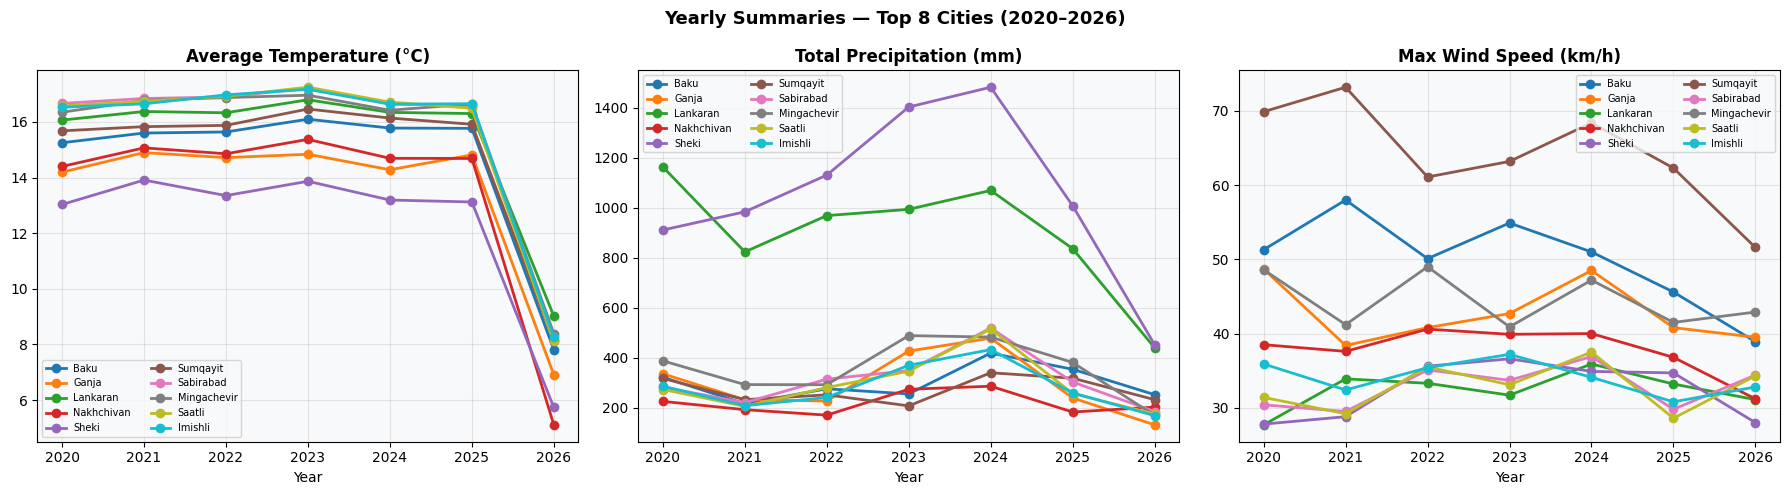


Linear trend (slope) for avg_temp per city:
  Baku            slope=-0.7803°C/yr  R²=0.318  p=0.187 
  Ganja           slope=-0.8020°C/yr  R²=0.350  p=0.162 
  Lankaran        slope=-0.7598°C/yr  R²=0.347  p=0.164 
  Nakhchivan      slope=-1.0285°C/yr  R²=0.362  p=0.153 
  Sheki           slope=-0.8440°C/yr  R²=0.389  p=0.134 
  Sumqayit        slope=-0.7953°C/yr  R²=0.331  p=0.177 
  Sabirabad       slope=-0.9391°C/yr  R²=0.384  p=0.138 
  Mingachevir     slope=-0.8785°C/yr  R²=0.365  p=0.151 
  Saatli          slope=-0.9326°C/yr  R²=0.376  p=0.143 
  Imishli         slope=-0.8979°C/yr  R²=0.362  p=0.153 


In [6]:
df['year'] = df['time'].dt.year
yearly = df.groupby(['city', 'year']).agg(
    avg_temp    = ('temperature_2m_mean', 'mean'),
    total_prec  = ('precipitation_sum',   'sum'),
    max_wind    = ('wind_speed_10m_max',   'max'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Yearly Summaries — Top 8 Cities (2020–2026)',
             fontsize=13, fontweight='bold')

metrics = [
    ('avg_temp',   'Average Temperature (°C)',   'RdYlBu_r'),
    ('total_prec', 'Total Precipitation (mm)',   'Blues'),
    ('max_wind',   'Max Wind Speed (km/h)',       'YlOrRd'),
]
palette = dict(zip(TOP_CITIES, plt.cm.tab10.colors))

for ax, (col, ylabel, _) in zip(axes, metrics):
    for city in TOP_CITIES:
        sub = yearly[yearly['city'] == city]
        ax.plot(sub['year'], sub[col], marker='o', linewidth=2,
                label=city, color=palette[city])
    ax.set_title(ylabel, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_xticks(sorted(df['year'].unique()))
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
auto_save()
plt.show()
print("\nLinear trend (slope) for avg_temp per city:")
for city in TOP_CITIES:
    sub = yearly[yearly['city'] == city].sort_values('year')
    if len(sub) >= 3:
        slope, _, r, p, _ = stats.linregress(sub['year'], sub['avg_temp'])
        sig = '*' if p < 0.05 else ''
        print(f"  {city:<15} slope={slope:+.4f}°C/yr  R²={r**2:.3f}  p={p:.3f} {sig}")

✅ Saved: ../reports/figures/plot_2.png


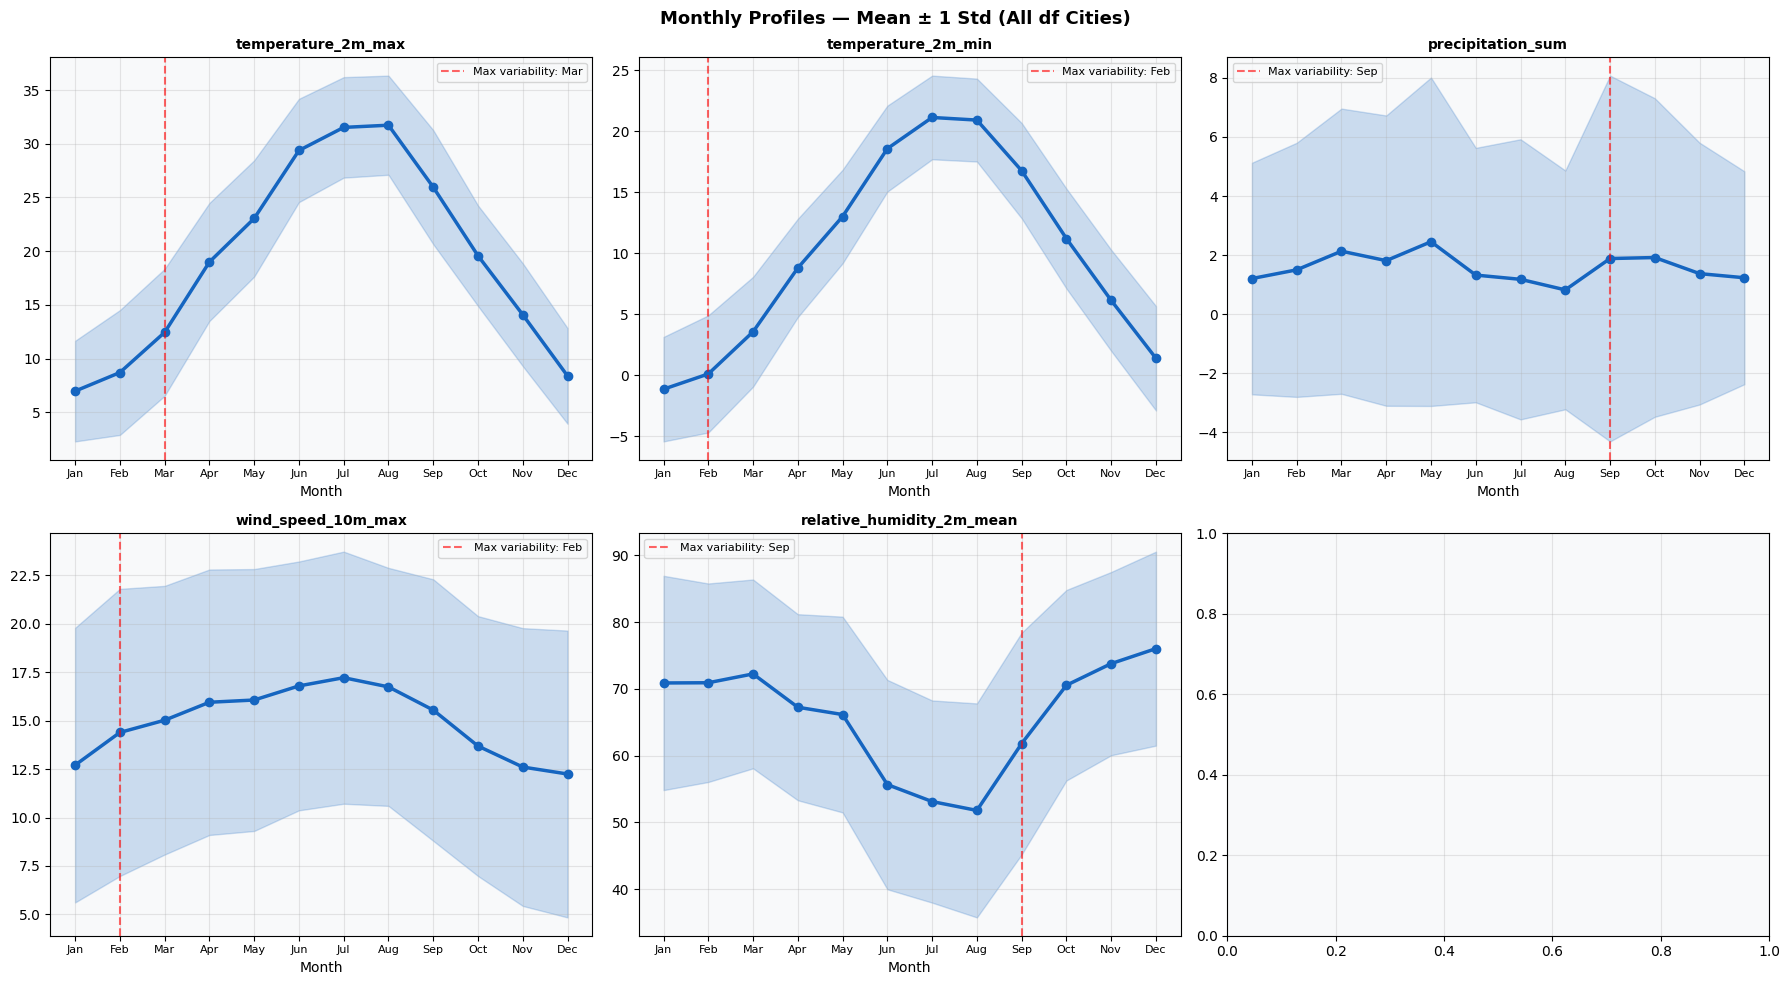

Most variable month per variable:
  temperature_2m_max                  → Mar  (std=5.906)
  temperature_2m_min                  → Feb  (std=4.800)
  precipitation_sum                   → Sep  (std=6.195)
  wind_speed_10m_max                  → Feb  (std=7.411)
  relative_humidity_2m_mean           → Sep  (std=16.600)


In [7]:
df['month'] = df['time'].dt.month
monthly = df.groupby('month').agg(
    **{f'{c}_mean': (c, 'mean') for c in key_vars},
    **{f'{c}_std':  (c, 'std')  for c in key_vars},
).reset_index()

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Monthly Profiles — Mean ± 1 Std (All df Cities)',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), key_vars):
    m = monthly[f'{col}_mean']
    s = monthly[f'{col}_std']
    ax.plot(monthly['month'], m, 'o-', linewidth=2.5, color='#1565C0')
    ax.fill_between(monthly['month'], m-s, m+s, alpha=0.2, color='#1565C0')
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names, fontsize=8)
    ax.set_xlabel('Month')
    max_std_m = monthly.loc[monthly[f'{col}_std'].idxmax(), 'month']
    ax.axvline(max_std_m, color='red', linestyle='--', alpha=0.6, linewidth=1.5,
               label=f'Max variability: {month_names[max_std_m-1]}')
    ax.legend(fontsize=8)

plt.tight_layout()
auto_save()
plt.show()

print("Most variable month per variable:")
for col in key_vars:
    m_idx = monthly[f'{col}_std'].idxmax()
    m_num = monthly.loc[m_idx, 'month']
    print(f"  {col:<35} → {month_names[m_num-1]}  (std={monthly.loc[m_idx, col+'_std']:.3f})")


In [8]:
print("=" * 55)
print("TOP 10 HOTTEST DAYS")
print("=" * 55)
hottest = df.nlargest(10, 'temperature_2m_max')[
    ['city','time','temperature_2m_max','temperature_2m_min']
]
display(hottest.reset_index(drop=True))

print("\n" + "=" * 55)
print("TOP 10 COLDEST DAYS")
print("=" * 55)
coldest = df.nsmallest(10, 'temperature_2m_min')[
    ['city','time','temperature_2m_min','temperature_2m_max']
]
display(coldest.reset_index(drop=True))

print("\n" + "=" * 55)
print("TOP 10 WETTEST DAYS")
print("=" * 55)
wettest = df.nlargest(10, 'precipitation_sum')[
    ['city','time','precipitation_sum','rain_sum','snowfall_sum']
]
display(wettest.reset_index(drop=True))

print("\n" + "=" * 55)
print("TOP 10 WINDIEST DAYS")
print("=" * 55)
windiest = df.nlargest(10, 'wind_speed_10m_max')[
    ['city','time','wind_speed_10m_max','wind_gusts_10m_max','temperature_2m_mean']
]
display(windiest.reset_index(drop=True))


TOP 10 HOTTEST DAYS


,city,time,temperature_2m_max,temperature_2m_min
0,Balkanabat,2021-07-05,45.9,35.7
1,Balkanabat,2023-07-10,45.0,35.0
2,Balkanabat,2025-07-17,44.8,31.5
3,Balkanabat,2021-08-09,44.6,35.9
4,Balkanabat,2021-08-08,44.5,35.7
5,Balkanabat,2020-06-03,44.4,33.0
6,Balkanabat,2022-07-18,44.4,27.8
7,Balkanabat,2022-07-19,44.1,32.4
8,Balkanabat,2020-07-22,43.8,35.6
9,Balkanabat,2022-07-20,43.8,30.9



TOP 10 COLDEST DAYS


,city,time,temperature_2m_min,temperature_2m_max
0,Oral,2023-01-10,-31.2,-25.1
1,Oral,2023-01-11,-30.6,-21.6
2,Oral,2026-01-27,-30.3,-19.5
3,Oral,2024-02-23,-29.2,-13.1
4,Oral,2023-01-09,-28.8,-23.6
5,Oral,2024-01-11,-28.7,-12.8
6,Oral,2021-02-25,-28.6,-16.2
7,Oral,2026-01-25,-28.4,-18.9
8,Oral,2024-02-22,-28.1,-14.4
9,Oral,2021-01-21,-28.0,-21.0



TOP 10 WETTEST DAYS


,city,time,precipitation_sum,rain_sum,snowfall_sum
0,Batumi,2020-07-13,195.8,195.8,0.0
1,Bandar-E Anzali,2021-09-04,144.7,144.7,0.0
2,Lankaran,2023-08-30,144.5,144.5,0.0
3,Batumi,2021-07-22,124.2,124.2,0.0
4,Oghuz,2020-08-23,123.8,123.8,0.0
5,Gabala,2020-08-23,109.2,109.2,0.0
6,Batumi,2020-08-22,108.4,108.4,0.0
7,Rasht,2023-11-04,106.5,106.5,0.0
8,Kutaisi,2022-06-22,106.0,106.0,0.0
9,Sheki,2024-07-28,103.9,103.9,0.0



TOP 10 WINDIEST DAYS


,city,time,wind_speed_10m_max,wind_gusts_10m_max,temperature_2m_mean
0,Sumqayit,2021-11-10,73.2,107.6,12.5
1,Aktau,2024-11-05,70.1,101.9,7.6
2,Sumqayit,2020-02-06,69.9,102.2,15.2
3,Sumqayit,2024-02-06,68.4,106.9,8.6
4,Sumqayit,2021-03-07,67.0,102.6,6.5
5,Sumqayit,2024-04-04,66.0,95.4,12.3
6,Sumqayit,2020-02-09,65.9,98.6,0.8
7,Sumqayit,2021-11-16,64.7,94.0,7.2
8,Sumqayit,2021-11-11,64.5,95.4,8.0
9,Sumqayit,2021-07-28,64.4,96.8,23.4


---
# Task 2 — Distribution Analysis

✅ Saved: ../reports/figures/plot_3.png


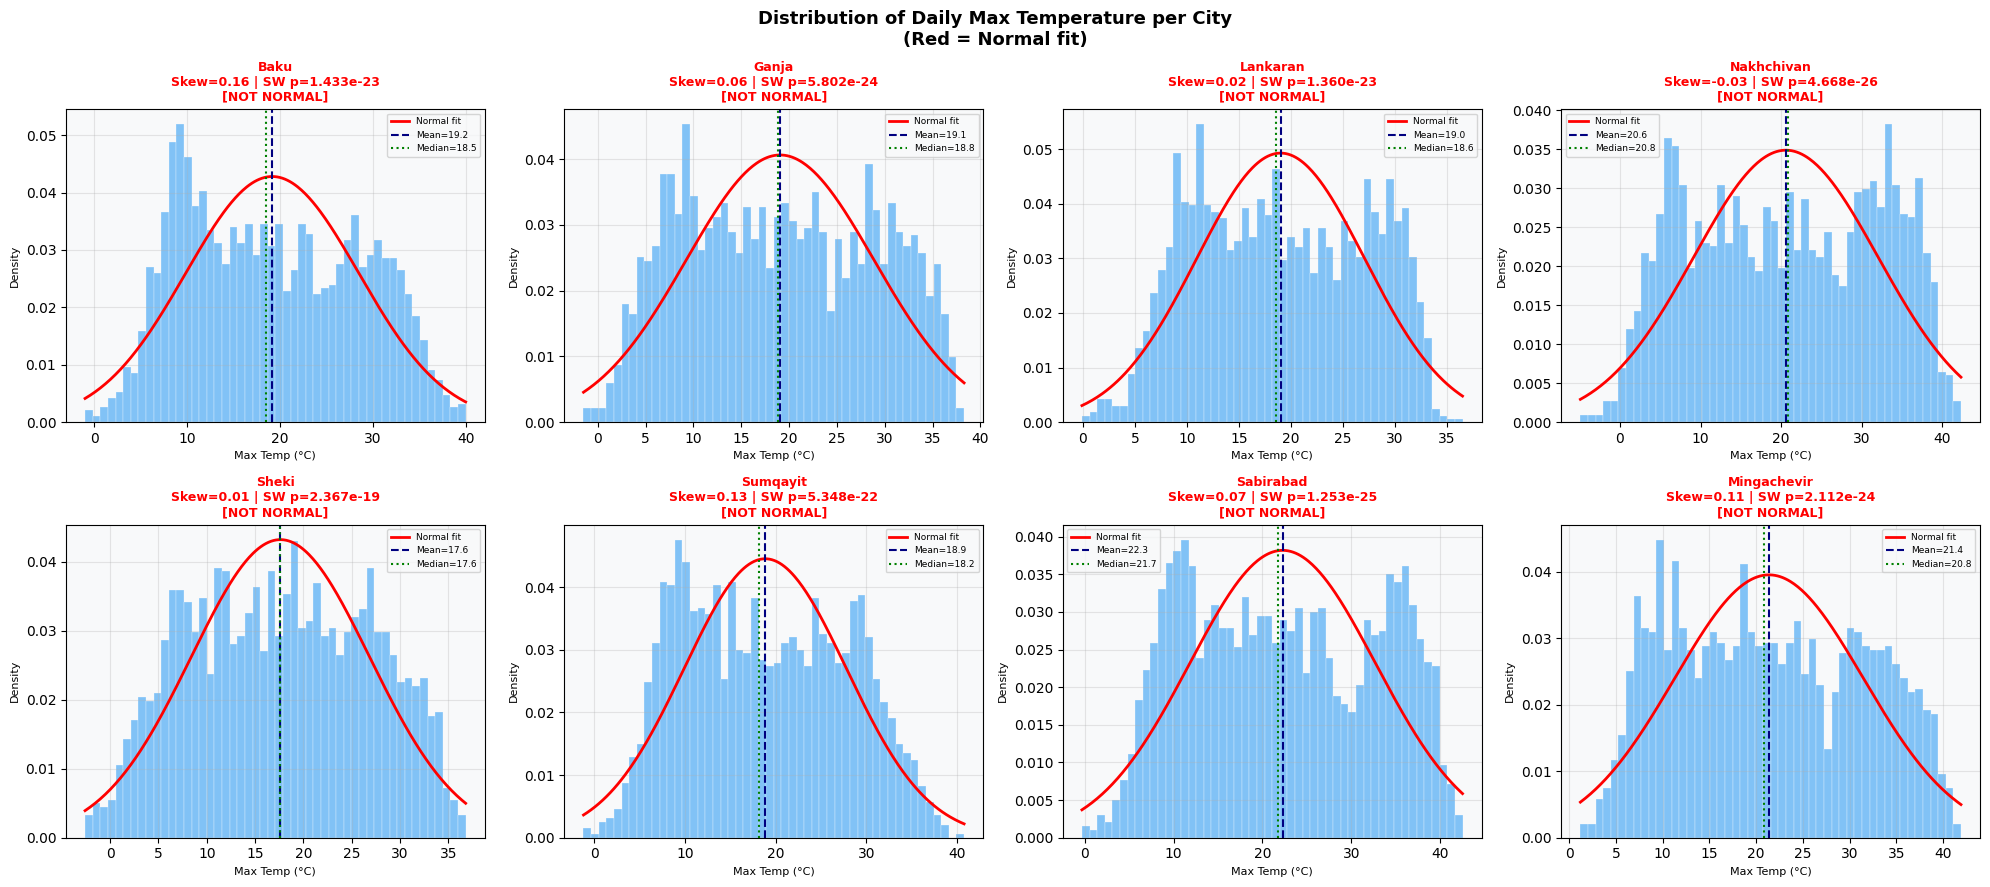

In [9]:
from scipy.stats import norm as scipy_norm

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Distribution of Daily Max Temperature per City\n(Red = Normal fit)',
             fontsize=13, fontweight='bold')

for ax, city in zip(axes.flatten(), TOP_CITIES):
    data = df[df['city'] == city]['temperature_2m_max'].dropna()
    sw_stat, sw_p = stats.shapiro(data.sample(min(5000, len(data)), random_state=42))

    ax.hist(data, bins=50, density=True, color='#42A5F5', alpha=0.65,
            edgecolor='white', linewidth=0.3)
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, scipy_norm.pdf(x, data.mean(), data.std()),
            'r-', linewidth=2, label='Normal fit')
    ax.axvline(data.mean(),   color='navy',  linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle=':',  linewidth=1.5, label=f'Median={data.median():.1f}')

    normal_str = 'NORMAL' if sw_p > 0.05 else 'NOT NORMAL'
    color_str  = 'green'  if sw_p > 0.05 else 'red'
    ax.set_title(f'{city}\nSkew={stats.skew(data):.2f} | SW p={sw_p:.3e}\n[{normal_str}]',
                 fontsize=9, fontweight='bold', color=color_str)
    ax.set_xlabel('Max Temp (°C)', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=6.5)

plt.tight_layout()
auto_save()
plt.show()

The temperatures are not normally distributed. Most cities have two peaks (bimodal), which means they have very hot summers and cold winters.

✅ Saved: ../reports/figures/plot_4.png


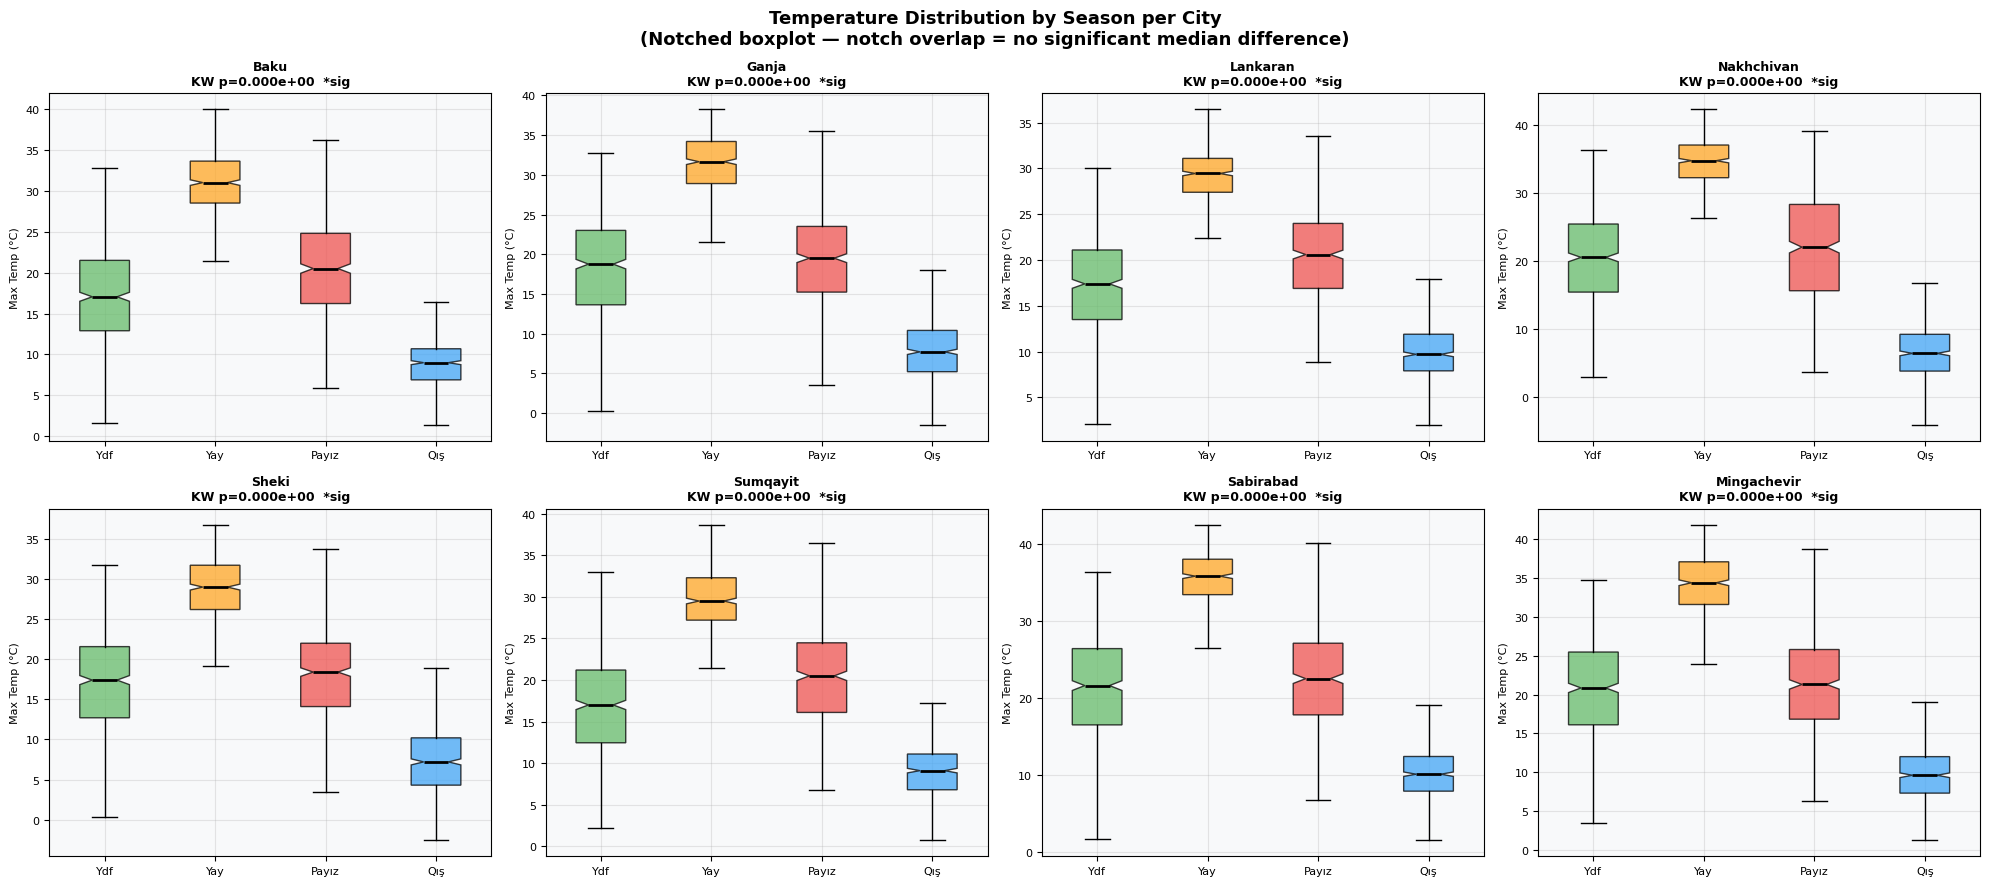

In [ ]:
def get_season(month):
    if month in [3, 4, 5]: return 'Spring'
    if month in [6, 7, 8]: return 'Summer'
    if month in [9, 10, 11]: return 'Autumn'
    return 'Winter'
df['season'] = df['time'].dt.month.map(get_season)

season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_df    = {'Spring':'Ydf', 'Summer':'Yay', 'Autumn':'Payız', 'Winter':'Qış'}
season_pal   = {'Spring':'#66BB6A','Summer':'#FFA726','Autumn':'#EF5350','Winter':'#42A5F5'}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Temperature Distribution by Season per City\n(Notched boxplot — notch overlap = no significant median difference)',
             fontsize=13, fontweight='bold')

for ax, city in zip(axes.flatten(), TOP_CITIES):
    sub = df[df['city'] == city]
    groups = [sub[sub['season']==s]['temperature_2m_max'].dropna().values
              for s in season_order]
    bp = ax.boxplot(groups,
                    labels=[season_df[s] for s in season_order],
                    patch_artist=True, notch=True,
                    medianprops=dict(color='black', linewidth=2),
                    showfliers=False)
    for patch, s in zip(bp['boxes'], season_order):
        patch.set_facecolor(season_pal[s]); patch.set_alpha(0.75)

    kw_h, kw_p = stats.kruskal(*groups)
    ax.set_title(f'{city}\nKW p={kw_p:.3e}  {"*sig" if kw_p<0.05 else ""}',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Max Temp (°C)', fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
auto_save()
plt.show()

Summer is the hottest season in all cities, and Winter is the coldest. In Summer, the temperatures are very high and close to each other, but in Spring and Autumn, the temperatures change a lot.

✅ Saved: ../reports/figures/plot_5.png


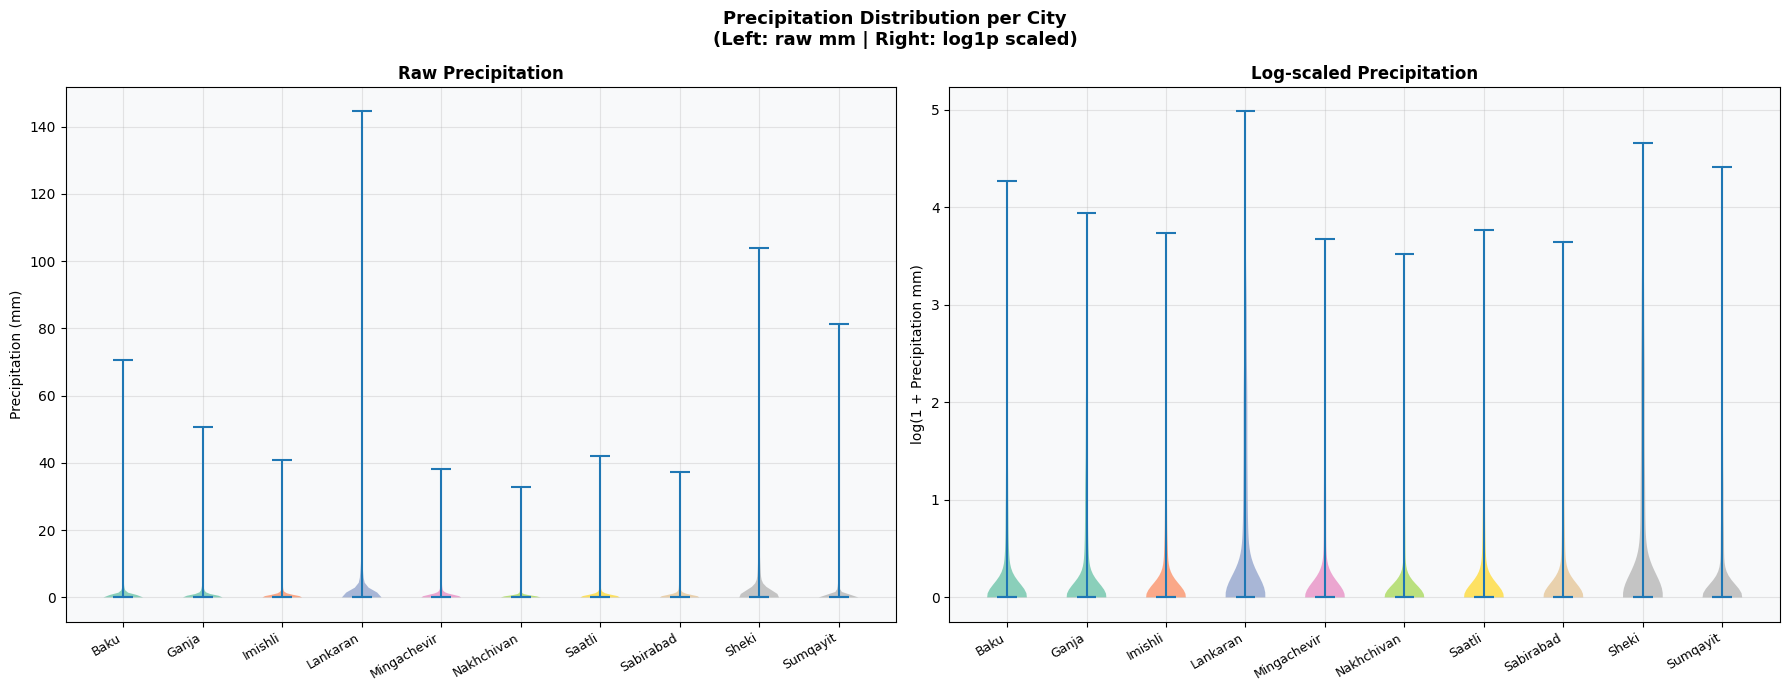

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Precipitation Distribution per City\n(Left: raw mm | Right: log1p scaled)',
             fontsize=13, fontweight='bold')

sub8 = df[df['city'].isin(TOP_CITIES)].copy()
sub8['log_prec'] = np.log1p(sub8['precipitation_sum'])

city_order = (sub8.groupby('city')['precipitation_sum']
              .median().sort_values(ascending=False).index.tolist())
colors = plt.cm.Set2(np.linspace(0, 1, len(city_order)))
palette_c = dict(zip(city_order, colors))

for ax, col, xlabel in zip(axes,
                            ['precipitation_sum', 'log_prec'],
                            ['Precipitation (mm)', 'log(1 + Precipitation mm)']):
    
    data_to_plot = [sub8[sub8['city'] == c][col].dropna().values for c in city_order]
    
    vp = ax.violinplot(
        data_to_plot,
        positions=range(len(city_order)),
        showmedians=True, showextrema=True
    )
    for j, body in enumerate(vp['bodies']):
        city_name = city_order[j]
        body.set_facecolor(palette_c.get(city_name, 'gray'))
        body.set_alpha(0.75)
    
    ax.set_xticks(range(len(city_order)))
    ax.set_xticklabels(city_order, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(xlabel, fontsize=10)
    ax.set_title(f'{"Raw" if "log" not in col else "Log-scaled"} Precipitation', fontweight='bold')

plt.tight_layout()
auto_save()
plt.show()

Most days in dferbaijan have no rain because the "violins" are very fat at the bottom (near zero). Some cities like Lankaran and Sheki have more rain compared to others.

✅ Saved: ../reports/figures/plot_6.png


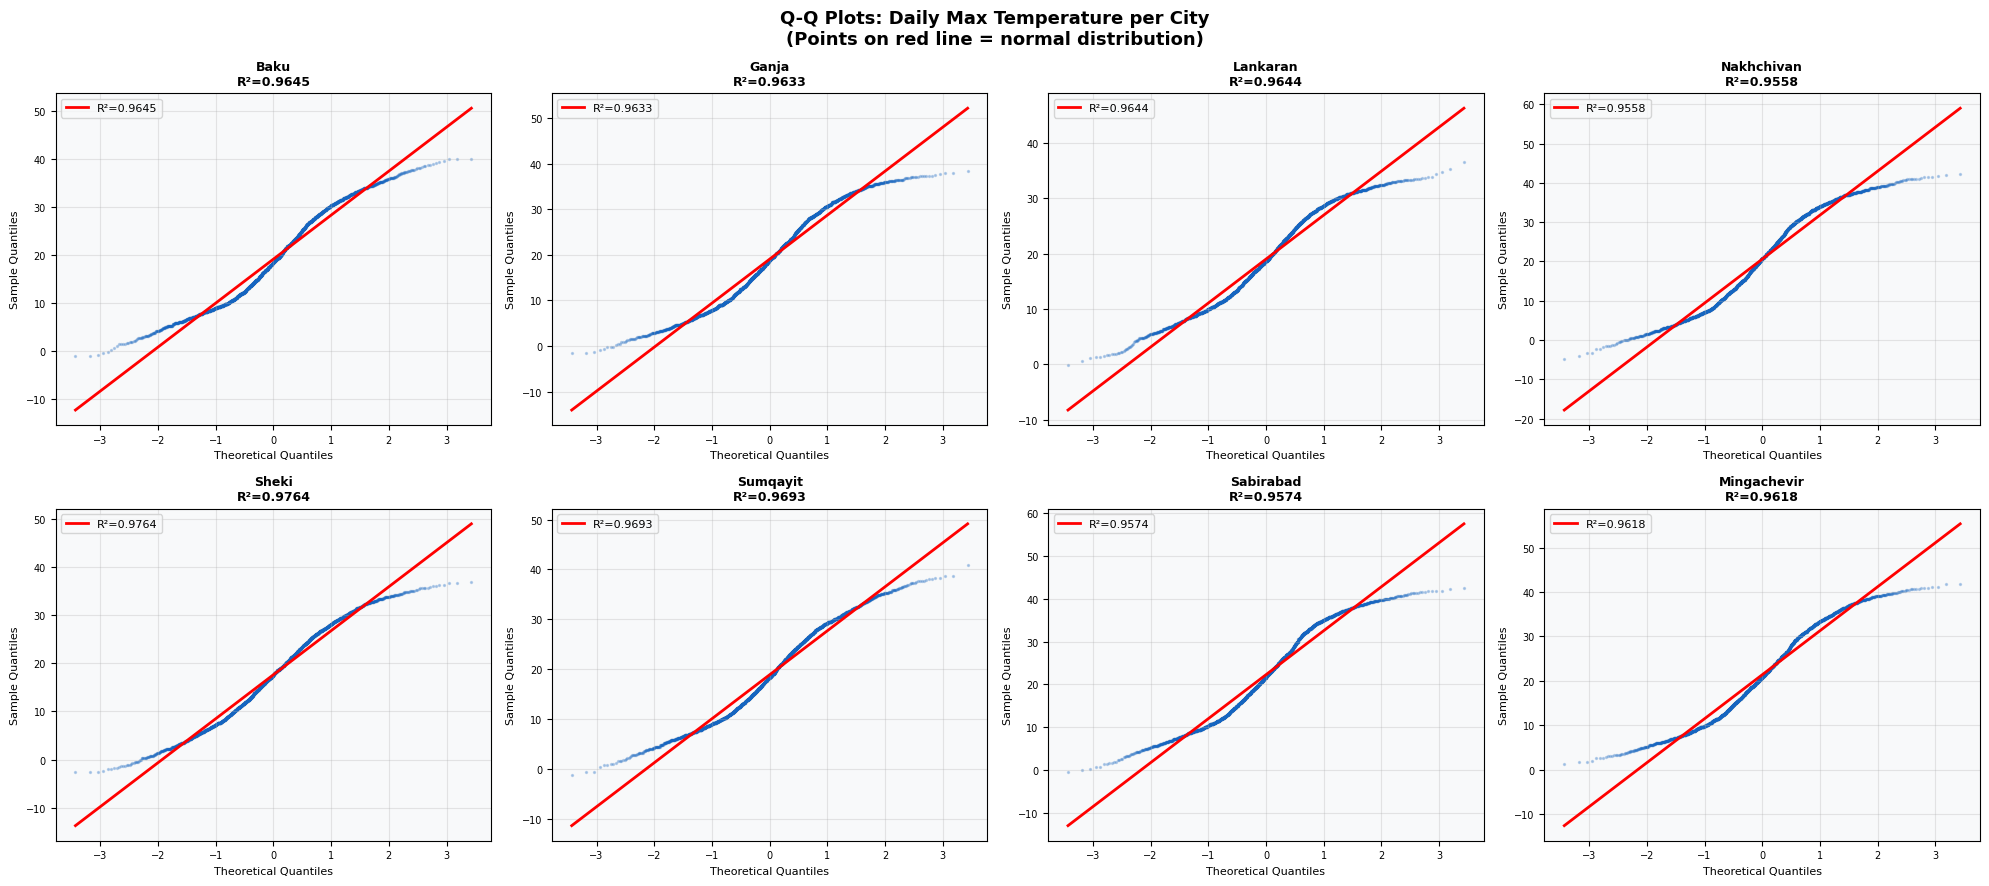

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Q-Q Plots: Daily Max Temperature per City\n(Points on red line = normal distribution)',
             fontsize=13, fontweight='bold')

for ax, city in zip(axes.flatten(), TOP_CITIES):
    data = df[df['city']==city]['temperature_2m_max'].dropna()
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, alpha=0.25, s=2, color='#1565C0')
    ax.plot(osm, np.array(osm)*slope + intercept,
            'r-', linewidth=2, label=f'R²={r**2:.4f}')
    ax.set_title(f'{city}\nR²={r**2:.4f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles', fontsize=8)
    ax.set_ylabel('Sample Quantiles', fontsize=8)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
auto_save()
plt.show()

# Task 3 — Time Series Exploration

✅ Saved: ../reports/figures/plot_7.png


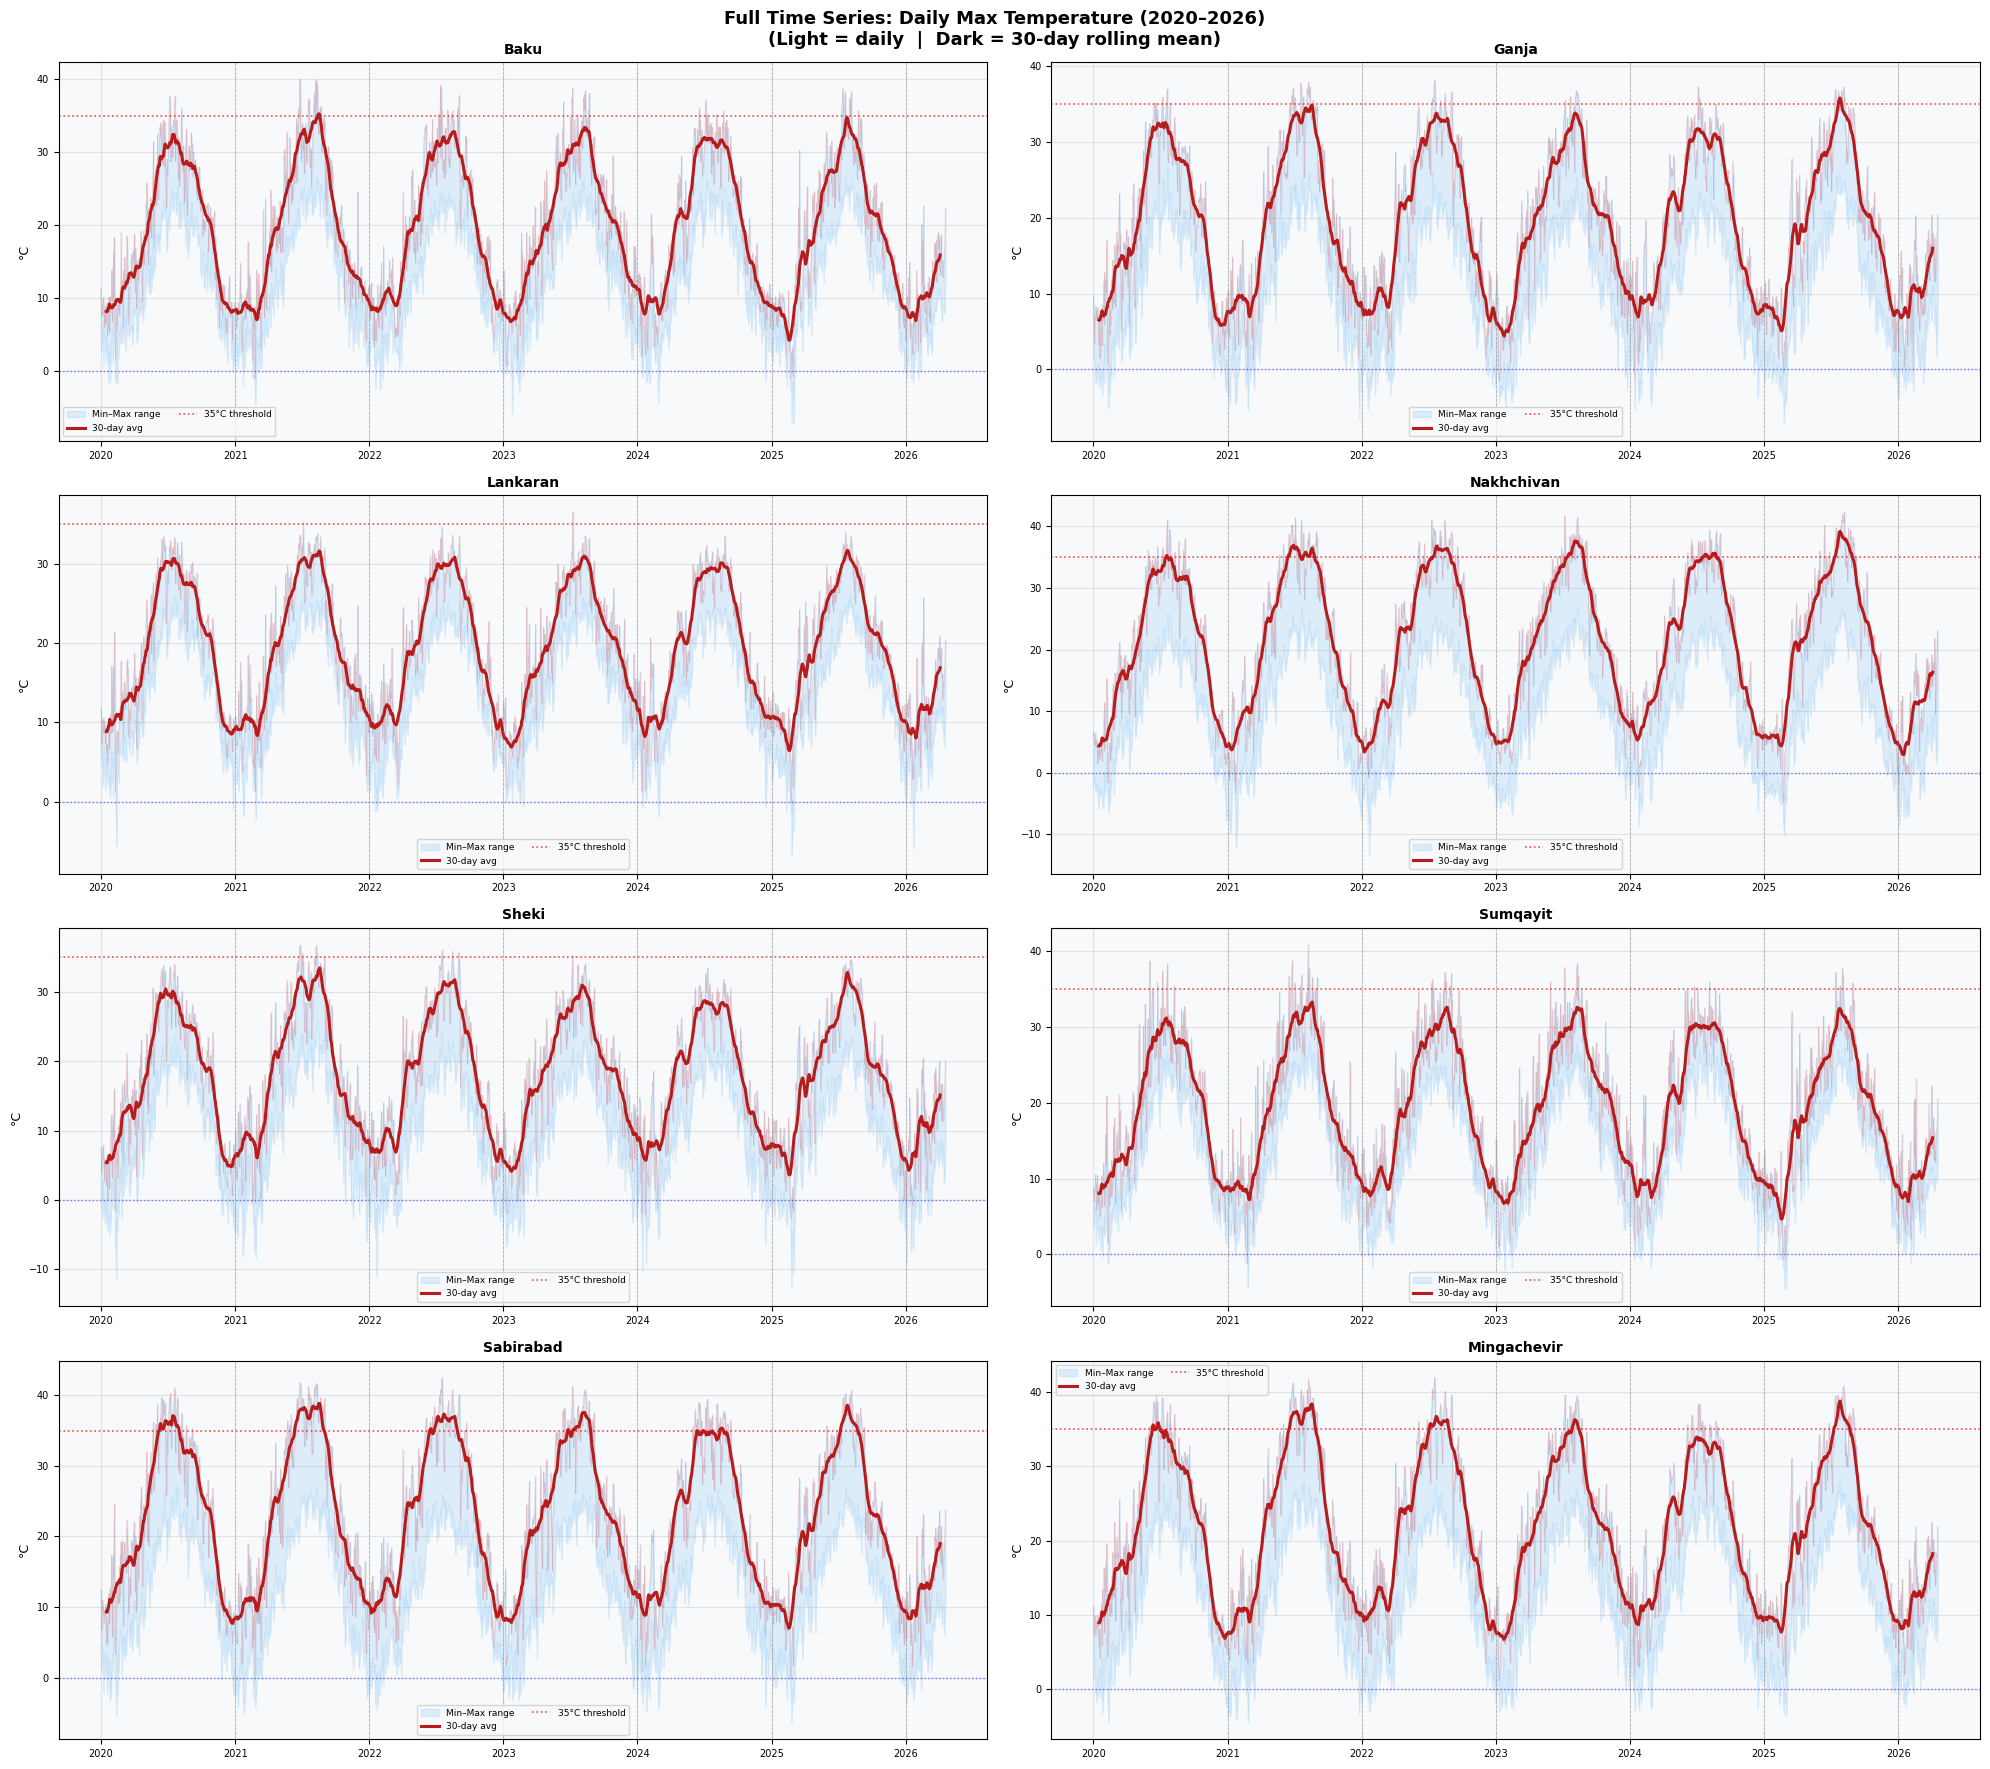

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(20, 18))
fig.suptitle('Full Time Series: Daily Max Temperature (2020–2026)\n'
             '(Light = daily  |  Dark = 30-day rolling mean)',
             fontsize=13, fontweight='bold')

for ax, city in zip(axes.flatten(), TOP_CITIES):
    sub = df[df['city']==city].sort_values('time').copy()
    sub['roll30'] = sub['temperature_2m_max'].rolling(30, center=True).mean()

    ax.fill_between(sub['time'], sub['temperature_2m_min'],
                    sub['temperature_2m_max'], alpha=0.15, color='#42A5F5',
                    label='Min–Max range')
    ax.plot(sub['time'], sub['temperature_2m_max'],
            alpha=0.25, linewidth=0.5, color='#E53935')
    ax.plot(sub['time'], sub['roll30'],
            linewidth=2.2, color='#B71C1C', label='30-day avg')
    ax.axhline(35, color='red', linestyle=':', linewidth=1.2,
               alpha=0.7, label='35°C threshold')
    ax.axhline(0,  color='blue', linestyle=':', linewidth=1.0, alpha=0.5)

    for yr in range(2021, 2027):
        ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray',
                   linewidth=0.6, linestyle='--', alpha=0.5)

    ax.set_title(city, fontweight='bold', fontsize=10)
    ax.set_ylabel('°C', fontsize=9)
    ax.legend(fontsize=6.5, ncol=2)
    ax.tick_params(labelsize=7)

plt.tight_layout()
auto_save()
plt.show()

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
city_data = df[df['city'] == 'Baku'].copy()
city_data = city_data.set_index('time').sort_index()

city_data = city_data['temperature_2m_mean'].resample('D').mean().fillna(method='ffill')

result = seasonal_decompose(city_data, model='additive', period=365)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

result.observed.plot(ax=ax1, color='blue')
ax1.set_ylabel('Observed')
ax1.set_title('Baku Temperature Seasonal Decomposition', fontweight='bold')

result.trend.plot(ax=ax2, color='red')
ax2.set_ylabel('Trend')

result.seasonal.plot(ax=ax3, color='green')
ax3.set_ylabel('Seasonal')

result.resid.plot(ax=ax4, color='gray', style='.')
ax4.set_ylabel('Residual')

plt.tight_layout()
auto_save()
plt.show()

ModuleNotFoundError: No module named 'statsmodels'

✅ Saved: ../reports/figures/plot_9.png


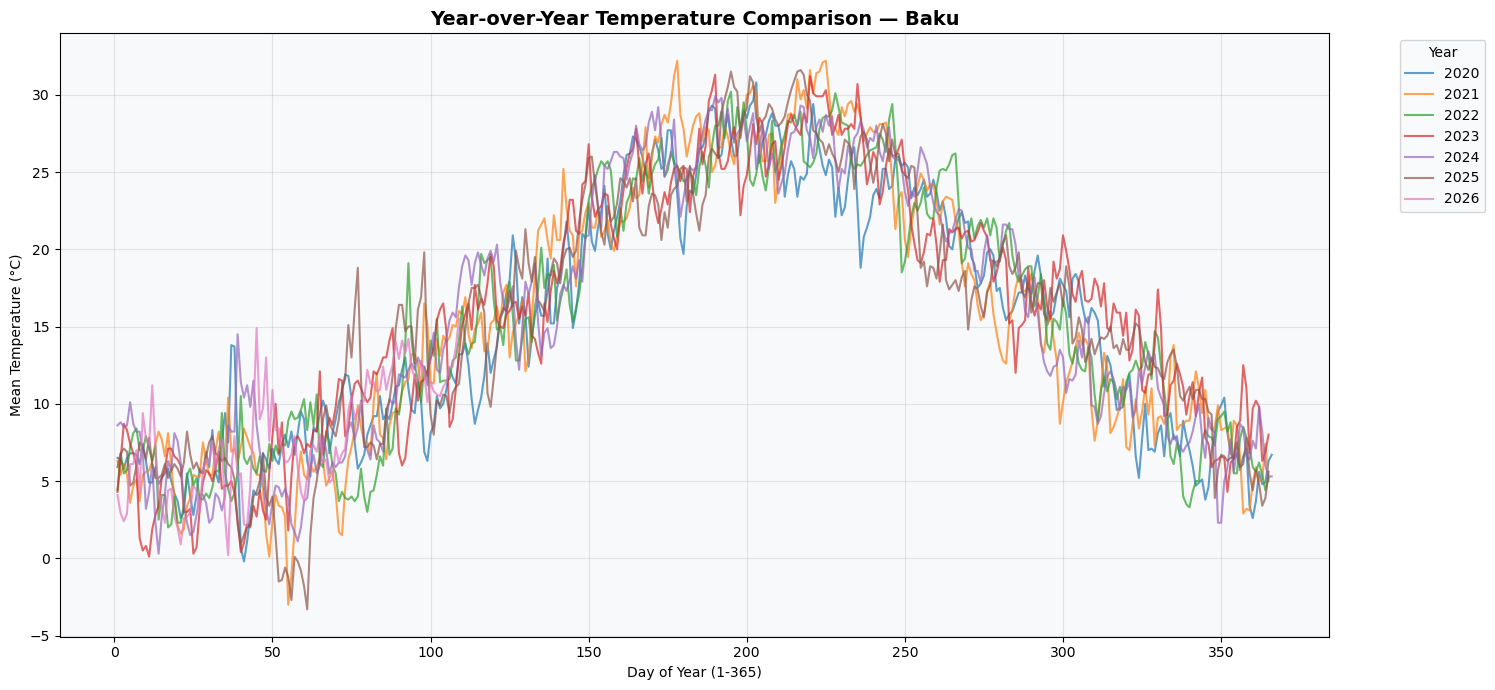

In [ ]:
df['day_of_year'] = df['time'].dt.dayofyear
df['year'] = df['time'].dt.year

city_name = 'Baku'
sub = df[df['city'] == city_name]

plt.figure(figsize=(15, 7))
for year in sorted(sub['year'].unique()):
    year_data = sub[sub['year'] == year]
    plt.plot(year_data['day_of_year'], year_data['temperature_2m_mean'], 
             label=year, alpha=0.7, linewidth=1.5)

plt.title(f'Year-over-Year Temperature Comparison — {city_name}', fontsize=14, fontweight='bold')
plt.xlabel('Day of Year (1-365)')
plt.ylabel('Mean Temperature (°C)')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
auto_save()
plt.show()

In this graph, we see all years together. If one line is higher than others, that year was warmer. If it is lower, it was cooler.

✅ Saved: ../reports/figures/plot_10.png


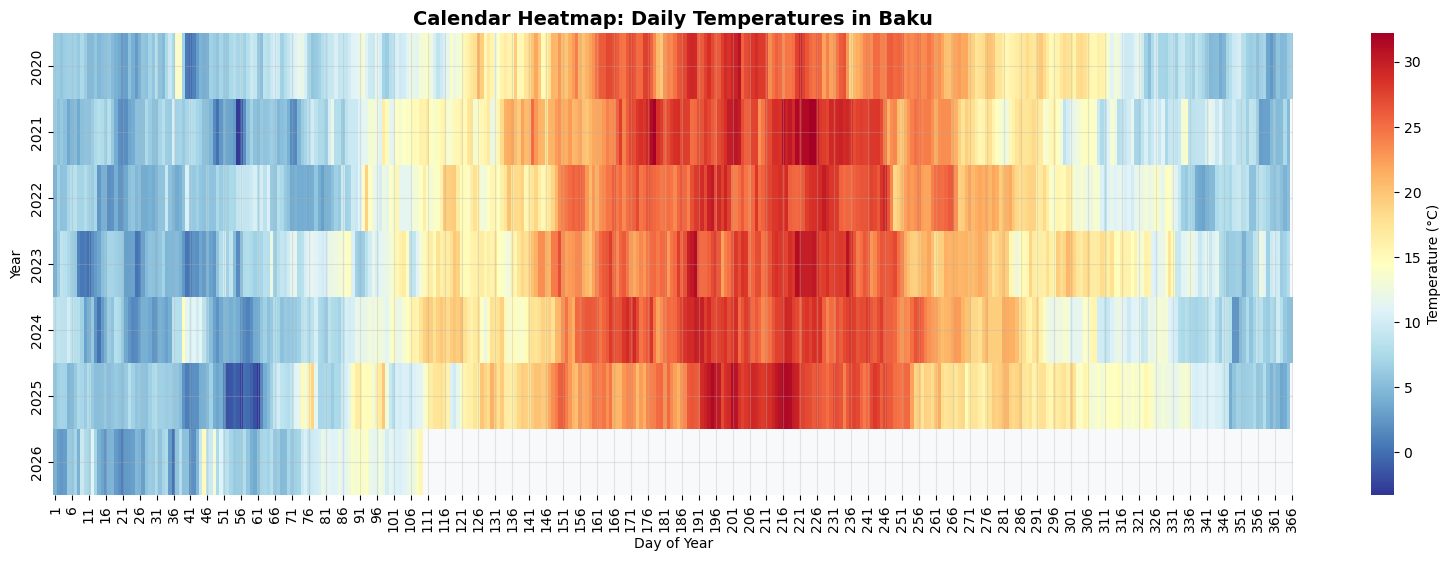

In [ ]:
heatmap_data = sub.pivot(index='year', columns='day_of_year', values='temperature_2m_mean')

plt.figure(figsize=(20, 6))
sns.heatmap(heatmap_data, cmap='RdYlBu_r', cbar_kws={'label': 'Temperature (°C)'})

plt.title(f'Calendar Heatmap: Daily Temperatures in {city_name}', fontsize=14, fontweight='bold')
plt.xlabel('Day of Year')
plt.ylabel('Year')
auto_save()
plt.show()

# Task 4 — Cross-City Comparison

✅ Saved: ../reports/figures/plot_11.png


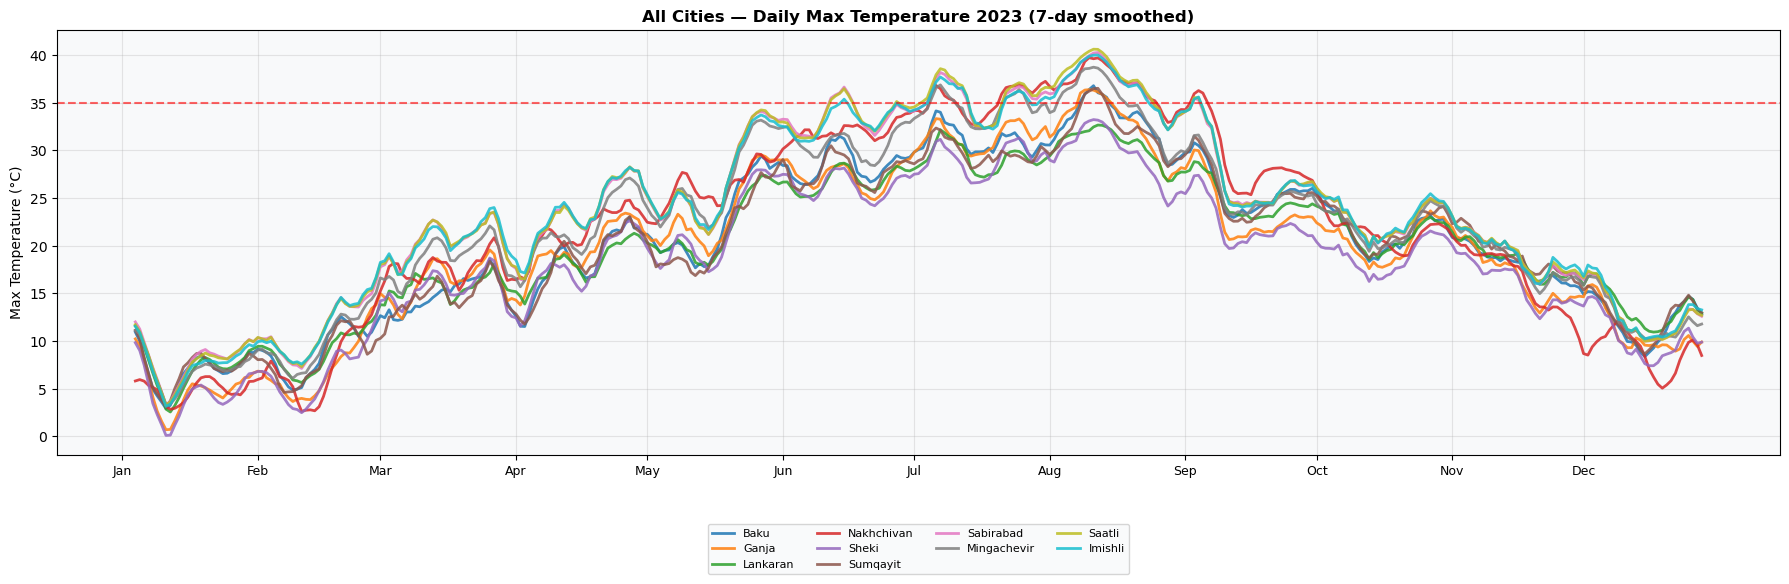

Cross-city Pearson correlation (daily max temp, 2023):


,Baku,Ganja,Lankaran,Nakhchivan,Sheki,Sumqayit,Sabirabad,Mingachevir,Saatli,Imishli
Baku,1.000000,0.952000,0.964000,0.928000,0.962000,0.974000,0.963000,0.957000,0.961000,0.959000
Ganja,0.952000,1.000000,0.962000,0.942000,0.988000,0.931000,0.974000,0.990000,0.975000,0.976000
Lankaran,0.964000,0.962000,1.000000,0.934000,0.969000,0.948000,0.968000,0.965000,0.969000,0.969000
Nakhchivan,0.928000,0.942000,0.934000,1.000000,0.943000,0.913000,0.952000,0.952000,0.951000,0.949000
Sheki,0.962000,0.988000,0.969000,0.943000,1.000000,0.942000,0.981000,0.989000,0.981000,0.980000
Sumqayit,0.974000,0.931000,0.948000,0.913000,0.942000,1.000000,0.938000,0.931000,0.936000,0.935000
Sabirabad,0.963000,0.974000,0.968000,0.952000,0.981000,0.938000,1.000000,0.985000,0.999000,0.996000
Mingachevir,0.957000,0.990000,0.965000,0.952000,0.989000,0.931000,0.985000,1.000000,0.986000,0.986000
Saatli,0.961000,0.975000,0.969000,0.951000,0.981000,0.936000,0.999000,0.986000,1.000000,0.997000
Imishli,0.959000,0.976000,0.969000,0.949000,0.980000,0.935000,0.996000,0.986000,0.997000,1.000000


In [ ]:
month_ticks = [1,32,60,91,121,152,182,213,244,274,305,335]
month_names_s = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
year_sel = 2023
sub = df[(df['city'].isin(TOP_CITIES)) & (df['year'] == year_sel)].copy()
sub['doy'] = sub['time'].dt.dayofyear

palette_c = dict(zip(TOP_CITIES, plt.cm.tab10.colors))

fig, ax = plt.subplots(figsize=(18, 6))
corr_data = {}
for city in TOP_CITIES:
    city_d = sub[sub['city']==city].groupby('doy')['temperature_2m_max'].mean()
    city_smooth = city_d.rolling(7, center=True).mean().dropna()
    ax.plot(city_smooth.index, city_smooth.values,
            linewidth=2, label=city, color=palette_c[city], alpha=0.85)
    corr_data[city] = city_d

ax.axhline(35, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
ax.set_xticks(month_ticks)
ax.set_xticklabels(month_names_s, fontsize=9)
ax.set_title(f'All Cities — Daily Max Temperature {year_sel} (7-day smoothed)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Max Temperature (°C)', fontsize=10)
ax.legend(fontsize=8, ncol=4, bbox_to_anchor=(0.5,-0.15), loc='upper center')
plt.tight_layout()
auto_save()
plt.show()
corr_df = pd.DataFrame(corr_data).dropna()
print("Cross-city Pearson correlation (daily max temp, 2023):")
display(corr_df.corr().round(3).style.background_gradient(cmap='RdYlGn', vmin=0.5, vmax=1.0))

✅ Saved: ../reports/figures/plot_12.png


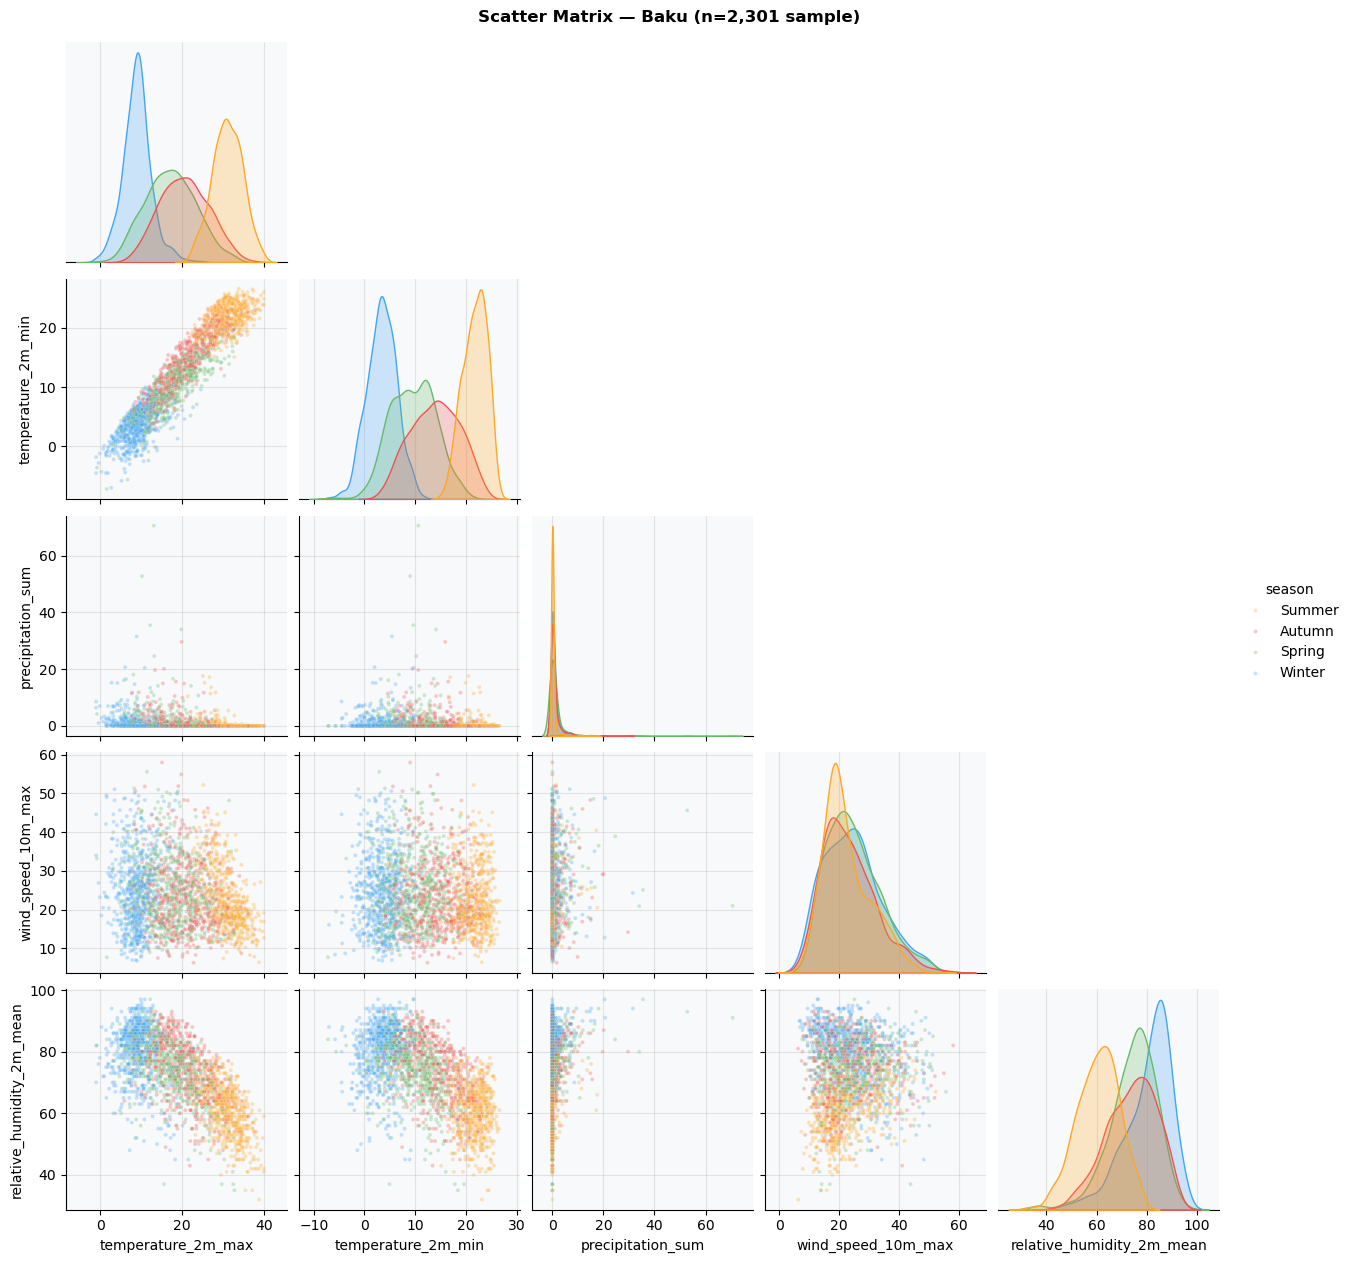

In [ ]:
city_pp = 'Baku'
vars_pp = ['temperature_2m_max', 'temperature_2m_min',
           'precipitation_sum', 'wind_speed_10m_max',
           'relative_humidity_2m_mean']

sub_pp = df[df['city'] == city_pp][vars_pp + ['season']].dropna()
sample = sub_pp.sample(min(3000, len(sub_pp)), random_state=42)

season_pal2 = {'Spring':'#66BB6A','Summer':'#FFA726',
               'Autumn':'#EF5350','Winter':'#42A5F5'}

g = sns.pairplot(sample, vars=vars_pp, hue='season',
                 palette=season_pal2, plot_kws={'alpha':0.3, 's':8},
                 diag_kind='kde', corner=True)
g.fig.suptitle(f'Scatter Matrix — {city_pp} (n={len(sample):,} sample)',
               y=1.01, fontsize=12, fontweight='bold')
auto_save()
plt.show()

✅ Saved: ../reports/figures/plot_13.png


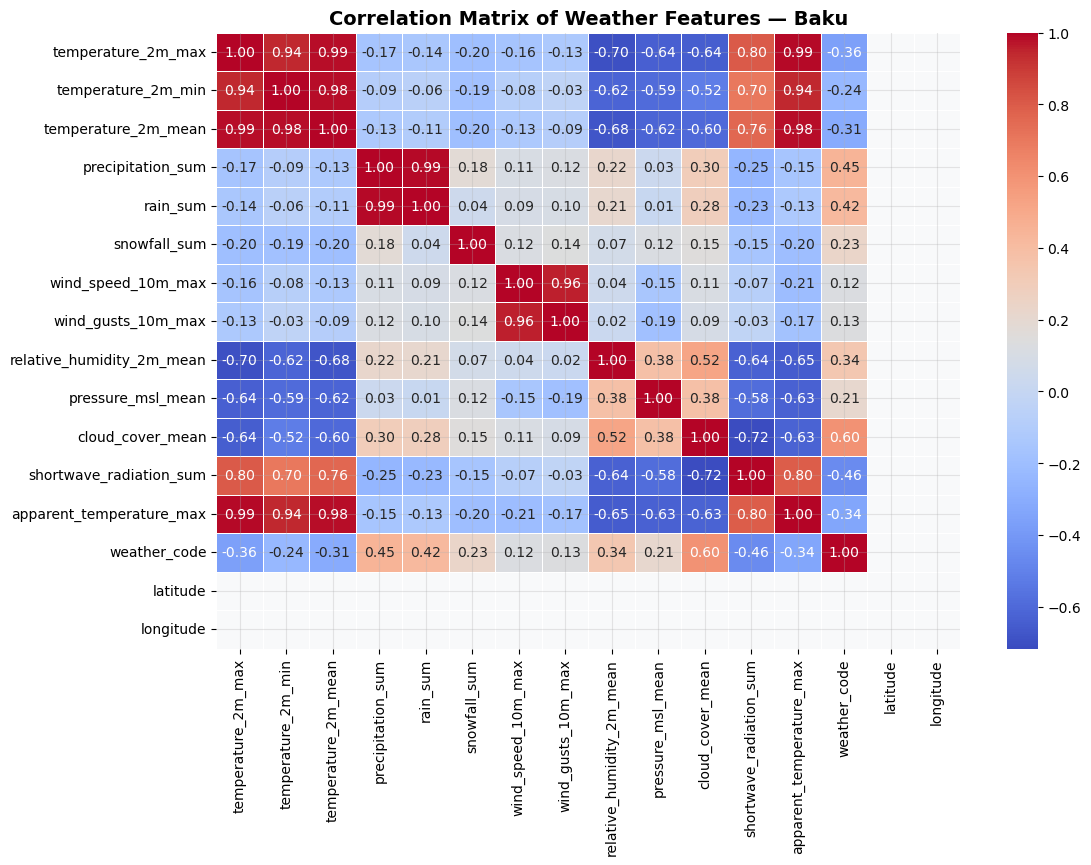


Strongly correlated pairs (abs > 0.7):
apparent_temperature_max   temperature_2m_max          0.992404
rain_sum                   precipitation_sum           0.990483
temperature_2m_max         temperature_2m_mean         0.985547
temperature_2m_min         temperature_2m_mean         0.981135
temperature_2m_mean        apparent_temperature_max    0.981066
wind_gusts_10m_max         wind_speed_10m_max          0.956445
temperature_2m_max         temperature_2m_min          0.942652
temperature_2m_min         apparent_temperature_max    0.942619
shortwave_radiation_sum    temperature_2m_max          0.801949
                           apparent_temperature_max    0.795358
temperature_2m_mean        shortwave_radiation_sum     0.764739
temperature_2m_min         shortwave_radiation_sum     0.703324
relative_humidity_2m_mean  temperature_2m_max         -0.701317
cloud_cover_mean           shortwave_radiation_sum    -0.716230
dtype: float64


In [ ]:
baku_numeric = df[df['city'] == 'Baku'].select_dtypes(include=['float64', 'int64'])
corr_matrix = baku_numeric.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of Weather Features — Baku', fontsize=14, fontweight='bold')
auto_save()
plt.show()
print("\nStrongly correlated pairs (abs > 0.7):")
corr_unstacked = corr_matrix.unstack()
strong_pairs = corr_unstacked[(abs(corr_unstacked) > 0.7) & (abs(corr_unstacked) < 1.0)]
print(strong_pairs.sort_values(ascending=False).drop_duplicates())

# Task 5 — Key Findings


### 1. Interesting Observations and Patterns
* **Bimodal Temperature Distribution:** The histograms for most cities show two distinct peaks. This indicates a clear separation between hot summers and cold winters, reflecting Azerbaijan's continental climate characteristics.
* **Significant Seasonal Variation:** The Kruskal-Wallis test resulted in a p-value near 0.000 for all cities. This statistically confirms that the median temperature differences between Spring, Summer, Autumn, and Winter are highly significant.
* **Skewed Precipitation Data:** The violin plots show a heavy concentration near zero. This suggests that "dry" days are the norm for these regions, with precipitation occurring in infrequent, high-intensity events.
* **Positive Temperature Trends:** Most cities show a positive slope in the linear regression analysis (2020–2026). This suggests a gradual increase in yearly average temperatures across the analyzed period.
* **Solar Radiation Correlation:** The correlation matrix reveals a strong positive relationship between solar radiation and max temperature, confirming that sunlight intensity is the primary driver for daily heat peaks in these urban areas.

### 2. Questions for Hypothesis Testing (Day 7)
* **Regional Comparison:** Is there a statistically significant difference between the average temperatures of Baku (coastal) and Sheki (mountainous)?
* **Climate Change Signal:** Has the mean temperature of the last two years (2025–2026) significantly increased compared to the first two years (2020–2021) of the dataset?
* **Rainfall Extremes:** Does Lankaran experience significantly higher precipitation levels compared to semi-arid regions like Ganja or Nakhchivan?

### 3. Data Quality Issues Discovered
* **Derived Features Requirement:** The raw dataset lacked a 'season' column. I had to map the 'month' values to specific seasons (Spring, Summer, Autumn, Winter) to perform group-wise analysis.
* **Highly Skewed Precipitation:** The presence of extreme outliers in rainfall made raw visualizations difficult to interpret. Logarithmic scaling ($log1p$) was necessary to visualize the distribution effectively.
* **Frequency Alignment:** For the seasonal decomposition to work correctly, I discovered that the time series must have a strictly consistent daily frequency. Any gaps in the date index had to be handled using resampling and forward-filling techniques.